# AQI Forecasting — SARIMA Model
**Dataset:** Jayanagar_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** SARIMA(1,1,1)(1,1,1)[7] — captures weekly seasonality

SARIMA extends ARIMA with a seasonal component for periodic patterns.
This is a univariate model — only AQI values are used for forecasting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Load & Preprocess Data


In [2]:
df = pd.read_csv('D:/AQI_Project/Data/Final/Jayanagar_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# Interpolate missing values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

# Daily aggregation — SARIMA uses AQI only (univariate)
daily = df.resample('D').mean().dropna(subset=['AQI'])

print(f'Daily records: {len(daily)}')
print(daily[['AQI']].head())


Daily records: 1826
                   AQI
Timestamp             
2021-01-01   71.081579
2021-01-02  128.337500
2021-01-03   94.291250
2021-01-04   69.166250
2021-01-05   70.670417


## 2. Seasonal Decomposition


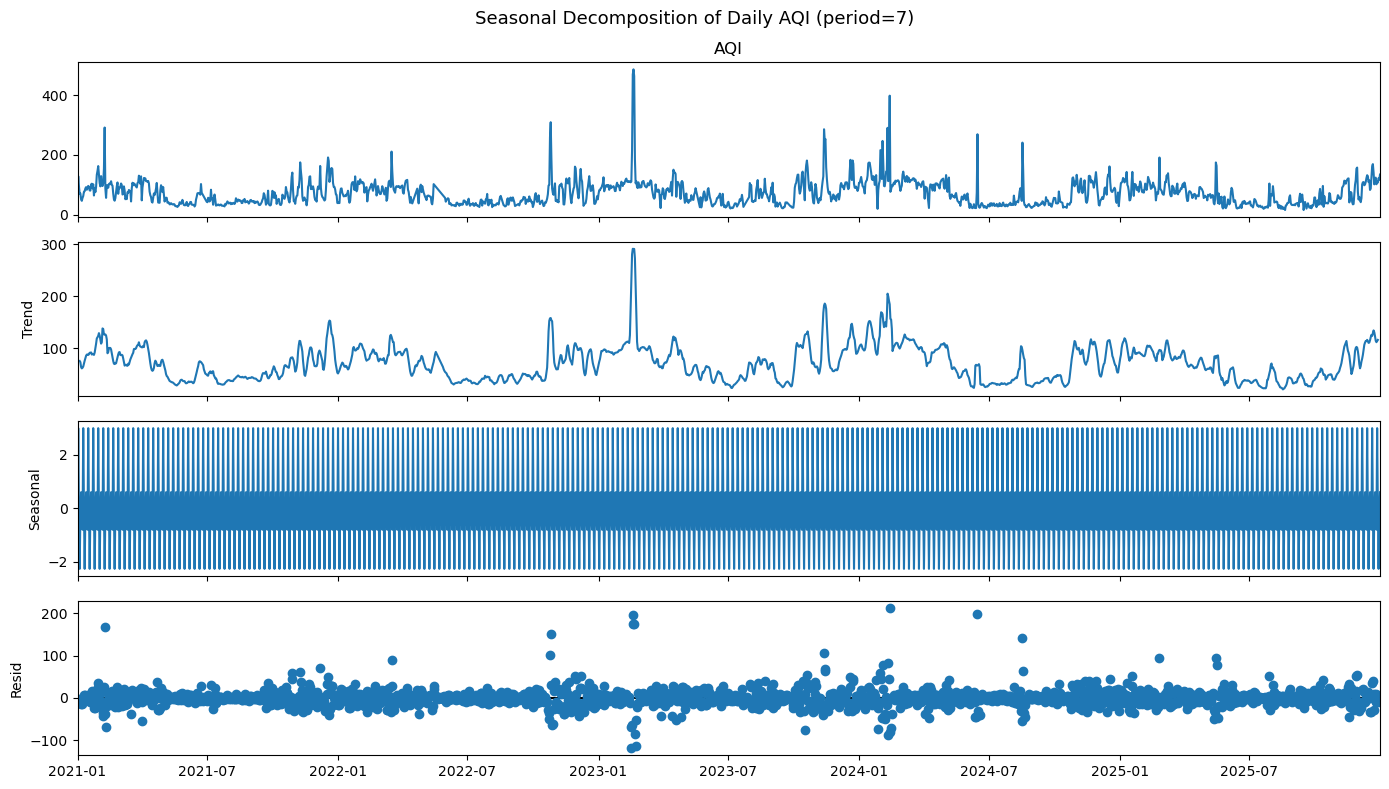

Weekly seasonal pattern clearly visible.


In [3]:
decomp = seasonal_decompose(daily['AQI'], model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Seasonal Decomposition of Daily AQI (period=7)', fontsize=13)
plt.tight_layout()
plt.savefig('sarima_decomposition_Jayanagar.png', dpi=150)
plt.show()
print('Weekly seasonal pattern clearly visible.')


## 3. Train/Test Split


In [4]:
# SARIMA is univariate — only the AQI series is needed
split_date = '2025-07-01'
train_y = daily['AQI'][:split_date].iloc[:-1]
test_y  = daily['AQI'][split_date:]

print(f'Train: {len(train_y)} | Test: {len(test_y)}')


Train: 1642 | Test: 184


## 4. Fit SARIMA(1,1,1)(1,1,1)[7]

Order: (p=1, d=1, q=1) non-seasonal  
Seasonal: (P=1, D=1, Q=1, s=7) weekly


In [5]:
model = SARIMAX(
    train_y,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)
print(fit.summary())


                                     SARIMAX Results                                     
Dep. Variable:                               AQI   No. Observations:                 1642
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -7605.967
Date:                           Fri, 15 May 2026   AIC                          15221.935
Time:                                   00:37:37   BIC                          15248.901
Sample:                               01-01-2021   HQIC                         15231.940
                                    - 06-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6768      0.012     55.193      0.000       0.653       0.701
ma.L1         -0.9571      0.008   -125.480

## 5. Forecast & Evaluation


In [6]:
forecast = fit.forecast(steps=len(test_y))
forecast.index = test_y.index

rmse = np.sqrt(mean_squared_error(test_y, forecast))
mae  = mean_absolute_error(test_y, forecast)
mape = np.mean(np.abs((test_y.values - forecast.values) / test_y.values)) * 100

print(f'SARIMA(1,1,1)(1,1,1)[7] Performance:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


SARIMA(1,1,1)(1,1,1)[7] Performance:
  RMSE : 40.45
  MAE  : 27.52
  MAPE : 42.87%


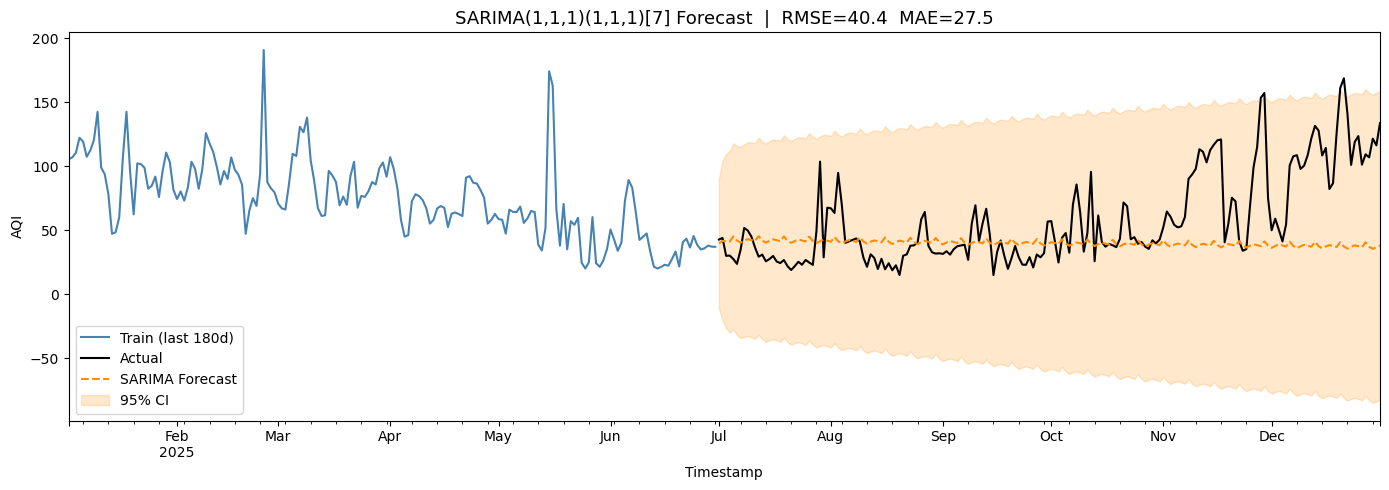

In [7]:
pred_obj = fit.get_forecast(steps=len(test_y))
ci = pred_obj.conf_int()
ci.index = test_y.index

fig, ax = plt.subplots(figsize=(14, 5))
train_y[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
test_y.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
forecast.plot(ax=ax, label='SARIMA Forecast', color='darkorange', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='darkorange', label='95% CI')
ax.set_title(f'SARIMA(1,1,1)(1,1,1)[7] Forecast  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('sarima_forecast_Jayanagar.png', dpi=150)
plt.show()


## 6. Residual Diagnostics


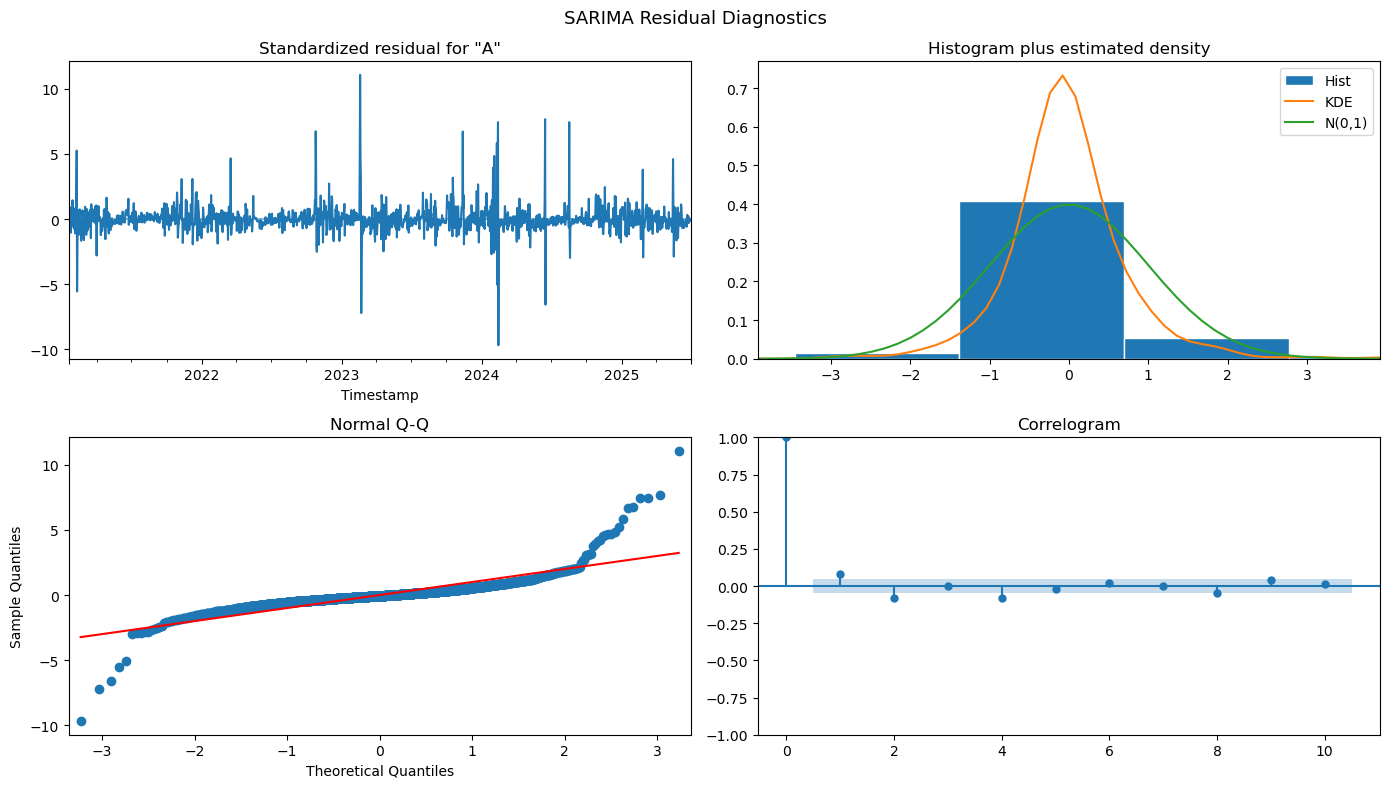

In [8]:
fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('sarima_diagnostics_Jayanagar.png', dpi=150)
plt.show()


## 7. AIC/BIC Comparison (Model Selection)

If you want to try alternative orders:


In [9]:
print(f'Selected model AIC : {fit.aic:.2f}')
print(f'Selected model BIC : {fit.bic:.2f}')
print()
print('Lower AIC/BIC = better model fit vs complexity trade-off.')


Selected model AIC : 15221.93
Selected model BIC : 15248.90

Lower AIC/BIC = better model fit vs complexity trade-off.
